In [18]:
#import important libraries 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load dataset
dataset = pd.read_csv(r"drug_regulatory_classification_dataset.csv")
dataset.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [3]:
print("Original dataset shape:", dataset.shape)

Original dataset shape: (60000, 30)


In [4]:
print(dataset.isnull().sum())

Dosage_mg                              0
Price_Per_Unit                         0
Production_Cost                        0
Marketing_Spend                        0
Clinical_Trial_Phase                   0
Side_Effect_Severity_Score             0
Abuse_Potential_Score                  0
Prescription_Rate                      0
Hospital_Distribution_Percentage       0
Pharmacy_Distribution_Percentage       0
Annual_Sales_Volume                    0
Regulatory_Risk_Score                  0
Approval_Time_Months                   0
Patent_Duration_Years                  0
R&D_Investment_Million                 0
Competitor_Count                       0
Recall_History_Count                   0
Adverse_Event_Reports                  0
Drug_Form                              0
Therapeutic_Class                      0
Manufacturing_Region                   0
Requires_Cold_Storage                  0
OTC_Flag                               0
High_Risk_Substance                    0
Insurance_Covera

In [5]:
dataset = dataset.dropna()

print("Dataset after removing NaN:", dataset.shape)

Dataset after removing NaN: (57000, 30)


In [6]:
#seperate input and output
x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [7]:
x.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Therapeutic_Class,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,Antibiotic,South,No,No,No,64.46,41.88,41.15,6.56,0.47
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,Antidepressant,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,Antiviral,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,Cardiovascular,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,Antidepressant,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36


In [8]:
y.head()

0    Non-Regulated Drug
1    Non-Regulated Drug
2    Non-Regulated Drug
3    Non-Regulated Drug
4    Non-Regulated Drug
Name: Target_Regulatory_Class, dtype: str

In [9]:
#load previously saved pipeline for use into te model
preprocess_pipeline = joblib.load('preprocess_pipeline.pkl')

In [10]:
#learn parameters
# Clean_data = preprocess_pipeline.fit_transform(x)

In [11]:
print(y.isna().sum())

0


In [12]:
#split Clean_data into training and testing have testing size of 20%
# Split data FIRST (avoid data leakage)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
#combine model cleaning and model traing in one structured pipeline
full_pipeline = Pipeline([
    ("preprocessing", preprocess_pipeline),
    ("model", LogisticRegression(max_iter=5000))
])

In [14]:
# #Convert data into DataFrame
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)

# #Make copy of training data
# train_data = x_train.copy()

# #Add target column
# train_data["target"] = y_train

# train_data = train_data.dropna()

# x_train = train_data.drop("target", axis=1)
# y_train = train_data["target"]

In [15]:
#initialize logistic regressing with higher iteration limit to avoid convergence error
# logistic_model = LogisticRegression(max_iter=2000)

In [16]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10, 50],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"]
}

In [19]:
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [20]:
#train model using training dataset
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [21]:
# Best model
best_model = grid_search.best_estimator_

In [22]:
#train model to make prediction on unseen data
# y_predict = logistic_model.predict(x_test)
# Prediction
y_predict = best_model.predict(x_test)

In [23]:
#checking type of y_test and y_predict to ensure both have same types
print(type(y_test))
print(type(y_predict))

<class 'pandas.Series'>
<class 'numpy.ndarray'>


In [24]:
#check which catagories exists in the read value vs predicted value
print(set(y_test))
print(set(y_predict))

{'Regulated Drug', 'Non-Regulated Drug'}
{'Regulated Drug', 'Non-Regulated Drug'}


In [25]:
#calculating count of classes
dataset["Target_Regulatory_Class"].value_counts()

Target_Regulatory_Class
Non-Regulated Drug    42130
Regulated Drug        14870
Name: count, dtype: int64

In [26]:
#change datatype of labels for proper comparision 
y_test = y_test.astype(str)
y_predict = y_predict.astype(str)

In [27]:
#measures how many predictions the model got right
accuracy = accuracy_score(y_test, y_predict)
print("Accuracy: ", accuracy)

Accuracy:  0.783859649122807


In [28]:
#compares actual vs predicted value and show classification errors
cm = confusion_matrix(y_test, y_predict)
print("Confusion Matrix: \n", cm)

Confusion Matrix: 
 [[7771  655]
 [1809 1165]]


In [29]:
##it give a complete summary of how well the model performed for every catagory
classif = classification_report(y_test, y_predict)
print("Classification Report: \n", classif)

Classification Report: 
                     precision    recall  f1-score   support

Non-Regulated Drug       0.81      0.92      0.86      8426
    Regulated Drug       0.64      0.39      0.49      2974

          accuracy                           0.78     11400
         macro avg       0.73      0.66      0.67     11400
      weighted avg       0.77      0.78      0.76     11400



In [30]:
#save model for reuse
# joblib.dump(logistic_model, 'logistic_model.pkl')
# Save model
joblib.dump(best_model, "logistic_model.pkl")

['logistic_model.pkl']

In [31]:
#previously saved Logistic Regression model from the file for reuse in prediction
drug_regulatory_classification_model = joblib.load('logistic_model.pkl')

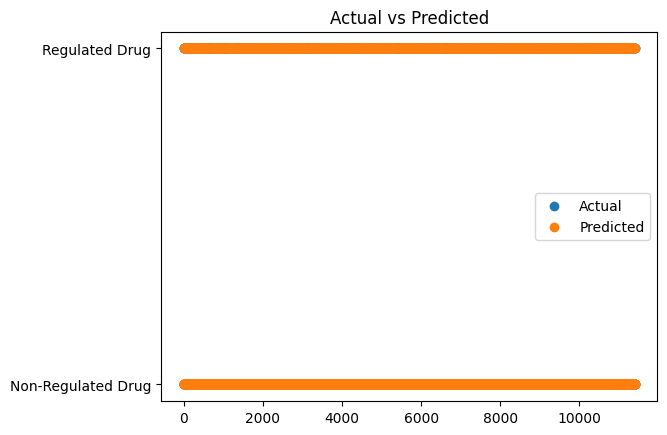

In [39]:
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_predict)), y_predict, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()